# REPORT

# 1.0 Abstract
This section contains a high-level overview of the research question, the dataset used, and the key findings and
insights.



# 2.0 Dataset Description

**A clear concise description of the dataset**

The dataset, titled "Impact of AI on Students," was sourced from Kaggle. It details the effects of Generative AI on students by tracking various attributes such as paid subscription status, weekly AI usage hours, and burnout risk.

**How the dataset was collected**

Despite inspecting the original source file ("ai_student_impact_dataset (1).csv"), information regarding the specific data collection methodology is unavailable. The dataset contains exactly 50,000 observations with zero missing values, which suggests it may be synthetically generated or heavily pre-processed. While the lack of provenance is a limitation, we opted to proceed with this dataset as it is widely utilized within the Kaggle community (featured in over 37 analytical models). Furthermore, it boasts a perfect Kaggle Usability Score of 10.0, achieving a 100% rating in criteria such as completeness and compatibility. We are operating under the assumption that the data simulates realistic student metrics or is a heavily sanitized compilation from various institutions where the authors imputed data to fill in the blanks. Additionally, the dataset appears to be highly relevant and recent; the oldest community models are only a month old, and new analyses are published frequently. This ongoing activity contributes to its 100% Kaggle Credibility rating—based on source engagement, public notebooks, and update frequency—which increases our confidence in using it for our current study.

**Potential implications of how the data was collected on the insights that will be generated**

Because the specific origin and sampling methods of the dataset are unknown, the insights generated from this study will be generalized. This lack of an identifiable target population decreases the external validity of our results, as different institutions have varying academic cultures and policies that impact student behavior. Furthermore, if the dataset is entirely synthetic, our findings may simply reflect the assumptions programmed into the creation algorithms by the original author, rather than genuine human trends.

* **Self-Reporting and Social Desirability Bias:** 
Some variables, for example Perceived_AI_Dependency, Anxiety_Level_During_Exams, and the weekly hour estimates are self-reported. If a university has a strict rule set, like Institutional_Policy with an outright AI ban, students might report lower AI usage than they actually had, or describe their primary use case in a different way. This can create an artificial separation between AI use and GPA changes in those groups, even when the real relationship is stronger. It can feel like AI is harmless in those datasets but it’s more like the reporting changed.
* **Construct Validity of Metrics:** 
The Skill_Retention_Score works like an objective counterbalance to self-assessments. It aims to measure retained knowledge, so analysts can check whether heavy dependence on AI boosts Post_Semester_GPA while reducing retained understanding over the same period.
* **Cross-Sectional vs. Longitudinal Limitations:** 
Since the tracking runs for one semester only, the takeaways lean toward fast behavioral shifts, not deep, slow habit building. Like, a student with high Weekly_GenAI_Hours might show an immediate GPA uplift, however the way it gradually compounds, on student burnout and long-term academic growth, needs observations over multiple terms. Otherwise it feels sorta limited, because we do not actually see the longer rhythm.

**Structure of the data**

*Student Academic Profile*
* **Student_ID** (INT): Unique identifier
* **Major_Category** (CATEGORICAL): STEM, Business, Humanities, Medical, Arts
* **Years_of_Study** (CATEGORICAL): Freshman, Sophomore, Junior, Senior, Graduate
* **Pre_Semester_GPA** (FLOAT): (1.00 - 4.00)
* **Post_Semester_GPA** (FLOAT): (1.00 - 4.00)
* **Skill_Retention_Score** (FLOAT): (0-100) how well students retain skills post-sem

*AI Usage Metrics*
* **Weekly_GenAI_Hours** (FLOAT): (0 - 40)
* **Primary_Use_Case** (CATEGORICAL): Copywriting/Drafting, Summarizing_Reading, Debugging/Troubleshooting, Ideation, Direct_Answer_Generation
* **Prompt_Engineering_Skill** (CATEGORICAL): Beginner, Intermediate, Advanced
* **Tool_Diversity** (INT): AI tools used
* **Paid_Subscription** (BOOLEAN): T/F
* **Perceived_AI_Dependency** (INT): Scale 1 (low) to 10 (high)

*Other*
* **Traditional_Study_Hours** (FLOAT): (1 - 36)
* **Institutional_Policy** (CATEGORICAL): Allowed_With_Citation, Strictly_Ban, Actively_Encouraged

*Student Well-Being*
* **Anxiety_Level_During_Exams** (INT): Scale 1 (minimal) to 10 (severe)
* **Burnout_Risk_Level** (CATEGORICAL): Low, Medium, High

# 3.0 Data Cleaning & Preprocessing

Although the dataset documentation claims perfect completeness and balanced distributions, its unverified origin necessitates strict quality assurance. We will programmatically verify the data's integrity by checking for null values, duplicate rows, inconsistent categorical encodings and outliers. Finally, we will perform feature engineering to create a new GPA_Change metric—derived from the pre- and post-semester GPAs—to directly measure academic shifts.

## 3.1 Dataset Loading and Program Initialization

This section is in charge of importing important libraries and reading the dataset for datacleaning.

In [12]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 5.5 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.6 MB 6.2 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.6 MB 6.1 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.6 MB 6.3 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.6 MB 6.4 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 6.4 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 6.0 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   ----------------

In [14]:
# USE THE FOLLOWING COMMAND IN NEW CODE BOX: !pip install regex
# Change regex to something like pandas if you dont have that library installed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import difflib
import regex as re
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import scipy.stats as stats
from scipy.stats import chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd


dataset = 'ai_student_impact_dataset (1).csv'
df = pd.read_csv(dataset)
print(f"Shape: {df.shape}")
print(df.info())
print(df.describe())

Shape: (50000, 16)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA      

## 3.2 Data Cleaning

### A. Formatting Categorical Names and Data Types

The first step in our data cleaning process was to ensure all variables were correctly typed and formatted. We programmatically checked the numerical columns to ensure no strings were incorrectly mapped (e.g., changing string '1' to integer 1). For categorical columns, we stripped accidental whitespaces and standardized the spelling and capitalization (e.g., standardizing "stem" to "STEM") using difflib to ensure consistency across the dataset.

In [4]:
# Check for Check for consistent categorical names
print("Checking For Consistent Categorical Names:\n")
categoricals = []
numericals = []
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col]): # if variable column is float
        numericals.append(col)

    elif pd.api.types.is_bool_dtype(df[col]): # if variable column is boolean
        categoricals.append(col)

    elif df[col].dtype == 'object':
      if not df[col].astype(str).str.isdigit().all(): # checks if column is categorical
        categoricals.append(col)

        df[col] = df[col].astype(str).str.strip() # fix whitespace
        raw_counts = df[col].value_counts()

        standard_mapping = {} # standardized the data values
        for unique_val in raw_counts.index:
            lowercase_version = unique_val.lower()
            if lowercase_version not in standard_mapping:
                standard_mapping[lowercase_version] = unique_val

        # Map values to their most frequent standard casing (e.g. stem to STEM)
        df[col] = df[col].apply(lambda x: standard_mapping[x.lower()])

        legitimate_categories = list(standard_mapping.values())

        def fix_typos(value): # fix spelling (ste to STEM)
            if value in legitimate_categories:
                return value
            matches = difflib.get_close_matches(value, legitimate_categories, n=1, cutoff=0.5)
            if matches:
                print(f"Fixed typo from {col}: Changed '{value}' to '{matches[0]}'")
                return matches[0]
            return value

        df[col] = df[col].apply(fix_typos)

      else: # fix numeric variables ('1' to 1)
        converted_series = pd.to_numeric(df[col], errors='coerce')
        if not converted_series.isnull().all():
            numericals.append(col)
            df[col] = converted_series

max_len = max(len(categoricals), len(numericals))

print(f"{'Index':<6} | {'Categorical Variables':<26} | {'Numerical Variables':<26}")
print("-" * 65)
for i in range(max_len):
    cat_val = categoricals[i] if i < len(categoricals) else ""
    num_val = numericals[i] if i < len(numericals) else ""
    print(f"{i:<6} | {cat_val:<26} | {num_val:<26}")

print("Successfully updated both categorical inconsistencies and numeric type mismatches across all variables\n")

Checking For Consistent Categorical Names:

Index  | Categorical Variables      | Numerical Variables       
-----------------------------------------------------------------
0      | Paid_Subscription          | Student_ID                
1      |                            | Pre_Semester_GPA          
2      |                            | Weekly_GenAI_Hours        
3      |                            | Tool_Diversity            
4      |                            | Traditional_Study_Hours   
5      |                            | Perceived_AI_Dependency   
6      |                            | Anxiety_Level_During_Exams
7      |                            | Post_Semester_GPA         
8      |                            | Skill_Retention_Score     
Successfully updated both categorical inconsistencies and numeric type mismatches across all variables



### B. Duplicate Record Check

To maintain data integrity, we checked the dataset for duplicate row entries based on the unique Student_ID. The check confirmed there were no duplicate entries, ensuring every row represents a distinct, unique student profile.

In [5]:
# Check for duplicate values
print("Checking For Duplicate Values:\n")
duplicate = False
duplicates = df.duplicated(subset=['Student_ID']).sum()
if duplicates != 0:
  print(f"\nNumber of duplicate Student IDs: {duplicates}")
  df = df.drop_duplicates(subset=['Student_ID'])
  print("duplicates have been dropped\n")
  duplicate = True
if duplicate == False:
  print("There are no duplicates. All IDS are unique\n")

Checking For Duplicate Values:

There are no duplicates. All IDS are unique



### C. Missing Values Analysis

We utilized pandas to scan every column for null or missing values. As promised by the Kaggle documentation, the dataset is perfectly complete. Zero missing values were found, meaning no data imputation or row dropping was required for this phase.

In [6]:
# Check for missing values
print("Checkign For Missing Values:\n")
missing = False
for col in df.columns:
  if df[col].isnull().any():
    ids = df[df[col].isnull()]['Student_ID'].tolist()

    print(f"Missing values in col: {col}")
    print(f"Affected Student ID: {ids}")
    missing = True
if missing == False:
  print("There are no missing values\n")

Checkign For Missing Values:

There are no missing values



### D. Handling Outliers
We utilized two methods to detect outliers. First, we established logical "hard limits" for human behavior. Because a week has 168 hours, we capped Weekly_GenAI_Hours and Traditional_Study_Hours at a maximum of 126 hours, accounting for sleep. We also capped Tool_Diversity and Perceived_AI_Dependency at logical bounds of 10. Second, for academic variables like GPAs and Skill Retention, we used the IQR (Interquartile Range) method to identify statistical extremes beyond 1.5x the IQR. No outliers were found to exceed these logical and statistical boundaries.

In [7]:
# Check for outliers
# Weekly_GenAI_Hours & Traditional_Study_Hours - assume a person can only use them for 126 hours per week each
# Tool_Diversity -  assume that a person can only use at most 10 tools
# Perceived_AI_Dependency - assume that the rating is within 1-5
# For the others, we use Iqr to determine what is considered an outlier
print("Checking For Outliers:\n")
hard_limits = {
    'Weekly_GenAI_Hours': 126.0,
    'Traditional_Study_Hours': 126.0,
    'Tool_Diversity': 10.0,
    'Perceived_AI_Dependency': 10.0
}

iqr_columns = [
    'Pre_Semester_GPA',
    'Post_Semester_GPA',
    'Anxiety_Level_During_Exams',
    'Skill_Retention_Score'
]

all_checked_variables = list(hard_limits.keys()) + iqr_columns

detailed_outliers_log = []

# header
print(f"{'Variable':<28} | {'Outlier Type':<20} | {'Lower Bound':<11} | {'Upper Bound':<11} | {'Number of Outliers':<18}")
print("-" * 96)

for col in all_checked_variables:
    if col in df.columns:

        if col in hard_limits: # if hard limit
            outlier_type = "Hard Limit"
            low_f = 0.0
            high_f = hard_limits[col]
        else: # if iqr
            outlier_type = "Statistical (IQR)"
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            low_f = Q1 - 1.5 * IQR
            high_f = Q3 + 1.5 * IQR

        outlier_mask = (df[col] < low_f) | (df[col] > high_f)
        outlier_count = outlier_mask.sum() # count outliers per column

        if outlier_count > 0:
            outlier_student_ids = df.loc[outlier_mask, 'Student_ID'].tolist()
            for student_id in outlier_student_ids: # print student id of outlier
                detailed_outliers_log.append(f"Outlier found in {col} (Student ID: {student_id})")

        print(f"{col:<28} | {outlier_type:<20} | {low_f:<11.2f} | {high_f:<11.2f} | {outlier_count:<18}")

print("\n" + "-"*40)
print("Outliers")
print("-"*40)

if detailed_outliers_log:
    for log in detailed_outliers_log[:20]:
        print(log)
    if len(detailed_outliers_log) > 20:
        print(f"... and {len(detailed_outliers_log) - 20} more outlier records found.")
else:
    print("No outliers detected across the dataset variables\n")

print("Data Cleaning of the Dataset has been completed")

Checking For Outliers:

Variable                     | Outlier Type         | Lower Bound | Upper Bound | Number of Outliers
------------------------------------------------------------------------------------------------
Weekly_GenAI_Hours           | Hard Limit           | 0.00        | 126.00      | 0                 
Traditional_Study_Hours      | Hard Limit           | 0.00        | 126.00      | 0                 
Tool_Diversity               | Hard Limit           | 0.00        | 10.00       | 0                 
Perceived_AI_Dependency      | Hard Limit           | 0.00        | 10.00       | 0                 
Pre_Semester_GPA             | Statistical (IQR)    | 1.80        | 4.55        | 328               
Post_Semester_GPA            | Statistical (IQR)    | 1.94        | 4.84        | 346               
Anxiety_Level_During_Exams   | Statistical (IQR)    | -1.50       | 10.50       | 0                 
Skill_Retention_Score        | Statistical (IQR)    | 39.26       | 112

## 3.3 Data Pre-processing

We first removed the student ID column as we won't need them for graph generation, we also make new column which is GPA change (positive means better grade and negative means lower grade)

In [8]:
# drop ID column, not needed for visualization and modeling
processed_df = df.drop(columns=['Student_ID']) 

# Feature Engineering = GPA_change
# check if grade got higher or lower
processed_df['GPA_Change'] = processed_df['Post_Semester_GPA'] - processed_df['Pre_Semester_GPA']

# Print confirmation
print("Feature Engineering Complete: Added 'GPA_Change' column.")
print(f"Current Dataframe Shape: {processed_df.shape}")
print(processed_df[['Pre_Semester_GPA', 'Post_Semester_GPA', 'GPA_Change']].head())

Feature Engineering Complete: Added 'GPA_Change' column.
Current Dataframe Shape: (50000, 16)
   Pre_Semester_GPA  Post_Semester_GPA  GPA_Change
0             2.418              2.393      -0.025
1             3.821              3.696      -0.125
2             3.398              3.499       0.101
3             3.789              4.000       0.211
4             3.635              3.798       0.163


# 4.0 Research Question & Exploratory Data Analysis 

The rapid integration of Generative AI in the 2020s sparked our group's interest in its true impact on university students. While AI is widely promoted as a beneficial learning assistant, prevailing discussions often warn that over-reliance may degrade a student's innate creativity and problem-solving skills. To empirically investigate these claims, we acquired a comprehensive dataset from Kaggle to explore the relationship between AI usage patterns and student outcomes.

Initially, we considered highly specific inquiries, such as whether AI functions better as a substitute teacher for explaining concepts, or if it merely serves to alleviate mundane tasks like syntax checking. We hypothesized that utilizing AI with advanced prompt engineering—treating it with strict parameters to control results—might improve a student's academic flexibility and reduce the stress of heavy workloads. Conversely, we questioned if complete reliance on AI would ultimately decrease a student's retained skill level.

By iteratively examining the dataset's available variables, we realized we could track both scholastic trajectories (via our engineered GPA_Change metric) and psychological indicators (such as Anxiety_Level_During_Exams and Burnout_Risk_Level). This allowed us to broaden our scope from specific, isolated behavioral questions into a comprehensive exploration of both academic and mental health impacts. This iterative process led to our finalized general research question:


## 4.1 Main Research Question:
To what extent does a student's reliance on generative AI tools significantly correlate with changes in academic performance and mental well-being?


## 4.2 EDA Questions

To systematically investigate our main research question, we formulated four specific Exploratory Data Analysis (EDA) questions. The visualizations and statistical summaries generated from these analyses will serve as the empirical foundation to support our final conclusions regarding the impact of AI on student outcomes.

### A. Does the distribution of academic burnout risk vary significantly across different academic major categories? 

### B. Is there a significant correlation between a student's weekly generative AI hours and their academic performance?

### C. Is there a correlation between the institutional policy on AI and the anxiety level of students?

To investigate this question, we first visualize the distribution of exam anxiety scores across the three different institutional policies (Allowed_With_Citation, Strictly_Ban, Actively_Encouraged) using a box plot. We then apply an ANOVA (Analysis of Variance) test to determine if the mean anxiety levels differ significantly between these groups.


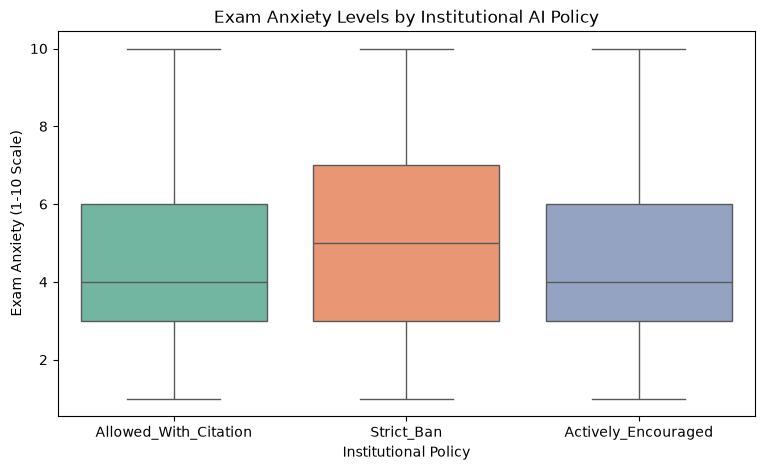

ANOVA F-statistic: 511.7927
P-value: 9.4609e-221

Conclusion: The p-value is < 0.05. There is a statistically significant difference in anxiety levels based on policy.


In [ ]:

# BoxPlot
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=processed_df, 
    x='Institutional_Policy', 
    y='Anxiety_Level_During_Exams',
    hue='Institutional_Policy',
    palette='Set2',
    legend=False
)
plt.title('Exam Anxiety Levels by Institutional AI Policy')
plt.xlabel('Institutional Policy')
plt.ylabel('Exam Anxiety (1-10 Scale)')
plt.show()

# ANOVA Test
groups = [group['Anxiety_Level_During_Exams'].values for name, group in processed_df.groupby('Institutional_Policy')]

f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("\nConclusion: The p-value is < 0.05. There is a statistically significant difference in anxiety levels based on policy.")
else:
    print("\nConclusion: The p-value is > 0.05. There is NO statistically significant difference.")

If the ANOVA test flags that there is a signifcance in the the difference in anxiety levels based on polocy, a post-hoc test is required. The group was initially going to go for Bonferroni Correction but Tukey's Honest Significant Difference is better so that we can tell the differences when comparing different categories.

In [ ]:
# Tukey's HSD Post-Hoc Test
tukey_results = pairwise_tukeyhsd(
    endog=processed_df['Anxiety_Level_During_Exams'],
    groups=processed_df['Institutional_Policy'],
    alpha=0.05
)

print(tukey_results)

               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
        group1                group2        meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------------------
  Actively_Encouraged Allowed_With_Citation   0.0035 0.9863 -0.0478 0.0548  False
  Actively_Encouraged            Strict_Ban   0.7675    0.0  0.7029 0.8322   True
Allowed_With_Citation            Strict_Ban   0.7641    0.0  0.7048 0.8233   True
---------------------------------------------------------------------------------


Conclusion: The ANOVA test confirms that there is a significant difference in atleast one of the categories and based on the Tukey Post-Hoc test we observed that Strict Ban has a higher chance of anxiety when it is compared to Actively encourage and Allowed with citation. While Actively encourage and Allowed with citation, has very minimal difference.

### D. How does prompt engineering proficiency vary across different years of study? Specifically, do senior students exhibit a higher distribution of advanced prompt engineering skills compared to freshmen? 